<a href="https://colab.research.google.com/github/DeepthiDaggula/Predictive-Analytics-Using-Historical-Data/blob/main/Predictive_Analytics_Using_historical_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive (1).zip


In [ ]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall()

print("Files extracted successfully!")

Files extracted successfully!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("housing_in_london_monthly_variables.csv")

df.head()

,date,area,average_price,code,houses_sold,no_of_crimes,borough_flag
0,1995-01-01,city of london,91449,E09000001,17.0,NaN,1
1,1995-02-01,city of london,82203,E09000001,7.0,NaN,1
2,1995-03-01,city of london,79121,E09000001,14.0,NaN,1
3,1995-04-01,city of london,77101,E09000001,7.0,NaN,1
4,1995-05-01,city of london,84409,E09000001,10.0,NaN,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13549 entries, 0 to 13548
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           13549 non-null  object 
 1   area           13549 non-null  object 
 2   average_price  13549 non-null  int64  
 3   code           13549 non-null  object 
 4   houses_sold    13455 non-null  float64
 5   no_of_crimes   7439 non-null   float64
 6   borough_flag   13549 non-null  int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 741.1+ KB


In [ ]:
df.isnull().sum()

,0
date,0
area,0
average_price,0
code,0
houses_sold,94
no_of_crimes,6110
borough_flag,0


In [ ]:
df = df.dropna()

df.shape

(7375, 7)

In [ ]:
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

df.head()

,date,area,average_price,code,houses_sold,no_of_crimes,borough_flag,year,month
72,2001-01-01,city of london,284262,E09000001,24.0,0.0,1,2001,1
73,2001-02-01,city of london,198137,E09000001,37.0,0.0,1,2001,2
74,2001-03-01,city of london,189033,E09000001,44.0,0.0,1,2001,3
75,2001-04-01,city of london,205494,E09000001,38.0,0.0,1,2001,4
76,2001-05-01,city of london,223459,E09000001,30.0,0.0,1,2001,5


In [ ]:
X = df[["year", "month", "houses_sold", "no_of_crimes", "borough_flag"]]

y = df["average_price"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
predictions = model.predict(X_test)

In [ ]:
print("R² Score:", r2_score(y_test, predictions))
print("Mean Squared Error:", mean_squared_error(y_test, predictions))

R² Score: 0.3878412592687034
Mean Squared Error: 21786028859.15433


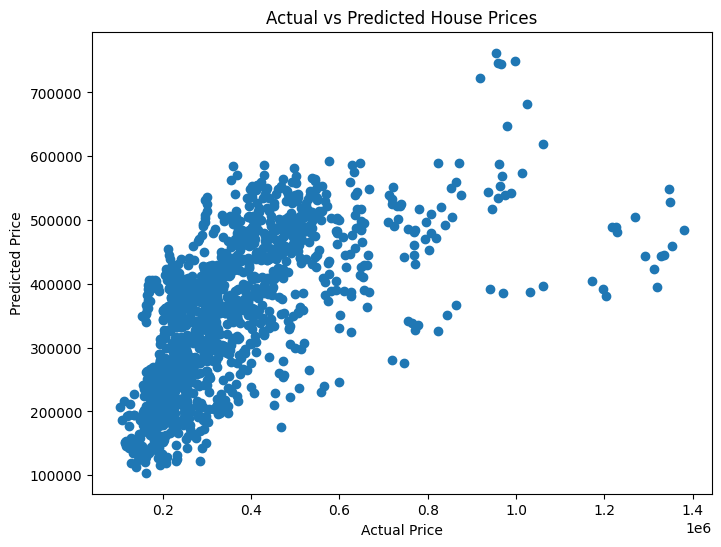

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [ ]:
sample = [[2026, 7, 250, 180, 1]]

prediction = model.predict(sample)

print("Predicted House Price:", prediction[0])

Predicted House Price: 578426.6455294862


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
